In [29]:
import numpy as np
import pandas as pd
import ipywidgets as widgets
from ipywidgets import Dropdown, Output, HBox, VBox
from IPython.display import display, clear_output
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
np.random.seed(42)

STEPS:
Load and split — separate data into train and test sets before touching the model
Fit — show the algorithm the training examples; it adjusts internal parameters to minimize prediction error
Predict — apply the trained model to the held-out test set
Evaluate — measure how well predictions match the true labels using a metric suited to your problem type

In [66]:
df = pd.read_csv("./student_scaled.csv")

In [ ]:
#defining our y, which are the final grades from the G3 column. Here, we are spliting the values within 
#the column and aligning them with the perfomance of the student - label zero being failing, label 1 being an
#equivalent of D to C gradesm label 2 being B to B+, and label 3 being A to A+
# y1 = pd.cut(
#     df["G3"],
#     bins=[-1, 9, 13, 17, 20],
#     labels=[0, 1, 2, 3]
# ).astype(int)

In [67]:
features1 = [
    "studytime",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
]

X_features1 = df[features1].copy()

X_features1.head()

,studytime,freetime,goout,Dalc,Walc,health,absences
0,-0.042286,-0.236010,0.801479,-0.540699,-1.003789,-0.399289,0.036424
1,-0.042286,-0.236010,-0.097908,-0.540699,-1.003789,-0.399289,-0.213796
2,-0.042286,-0.236010,-0.997295,0.583385,0.551100,-0.399289,0.536865
3,1.150779,-1.238419,-0.997295,-0.540699,-1.003789,1.041070,-0.464016
4,-0.042286,-0.236010,-0.997295,-0.540699,-0.226345,1.041070,-0.213796


In [69]:
#identifying the X values/independent features that we think will impact the Y - whether or not student has family support
# features = ["studytime", 

X1 = df[features1]
Y1 = pd.cut(
    df["G3"],
    bins=[-1, 9, 13, 17, 20],
    labels=[0, 1, 2, 3]
).astype(int)

In [ ]:
#assinging our independent and dependent variables to training and test variables.
#leaving 20% of our data out to be see how well model performs on unseen data 

from sklearn.model_selection import train_test_split

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1,
    Y1,
    test_size=0.2,
    random_state=42
)

In [ ]:
#LIN.REG

In [72]:
features2 = [
    "studytime",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
]

In [78]:
#LINEAR REGRESSION MODEL
X2 = df[features2]
Y2 = df["G3"]

In [79]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    Y2,
    test_size=0.2,
    random_state=42
)

In [84]:
#importing linear regression package
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()

model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

In [85]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test2, y_pred2)

print(r2)

0.003943774416108714


In [86]:
coefficients = pd.DataFrame({
    "Feature": X2.columns,
    "Coefficient": model.coef_
})

print(coefficients)

     Feature  Coefficient
0  studytime     0.098553
1   freetime     0.048164
2      goout    -0.089168
3       Dalc    -0.094666
4       Walc     0.028259
5     health    -0.086835
6   absences    -0.068964


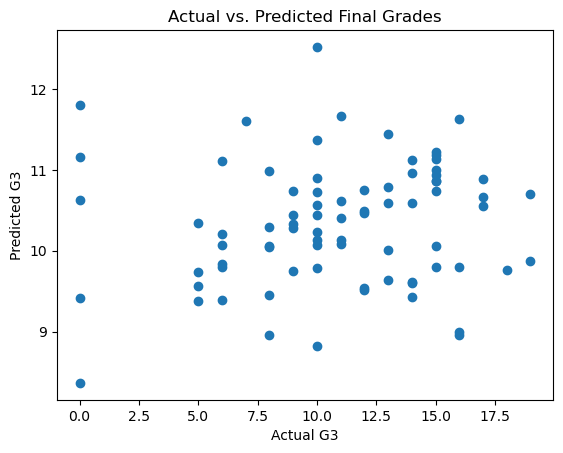

In [87]:
import matplotlib.pyplot as plt

plt.scatter(y_test2, y_pred2)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs. Predicted Final Grades")

plt.show()

In [88]:
y_pred2 = model.predict(X_test2)

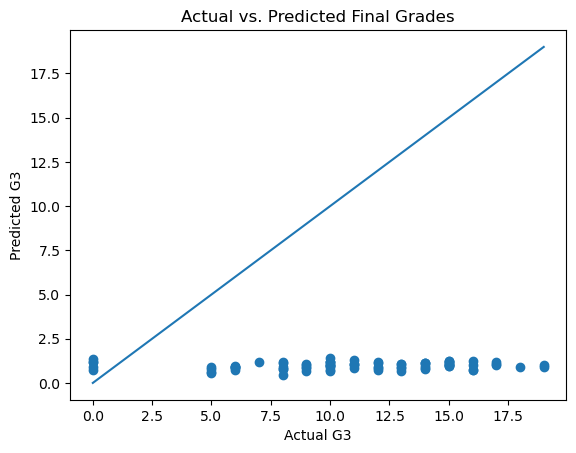

In [89]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(y_test2, y_pred2)

# Perfect prediction line
plt.plot(
    [y_test2.min(), y_test2.max()],
    [y_test2.min(), y_test2.max()]
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs. Predicted Final Grades")

plt.show()

Model 3 - Also Linear Regression

In [92]:
features3 = ["G1", "G2"]

X3 = df[features3]
Y3 = df["G3"]

In [93]:
from sklearn.model_selection import train_test_split

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3,
    Y3,
    test_size=0.2,
    random_state=42
)

In [95]:
model3 = LinearRegression()

model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

In [97]:
r3 = r2_score(y_test3, y_pred3)

print(r3)

0.7945936216805896


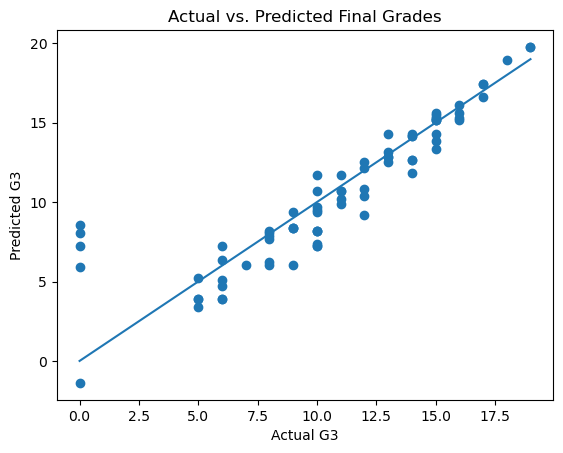

In [98]:

plt.scatter(y_test3, y_pred3)

# Perfect prediction line
plt.plot(
    [y_test3.min(), y_test3.max()],
    [y_test3.min(), y_test3.max()]
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs. Predicted Final Grades")

plt.show()

In [ ]:
#importing logistic regression package
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [39]:
#fiting our training date to the model
model.fit(X_train1, y_train1)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [40]:
y_pred1 = model.predict(X_test1)

In [41]:
from sklearn.metrics import accuracy_score

accuracy1 = accuracy_score(y_test1, y_pred1)

print(accuracy1)

0.5316455696202531


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test1, y_pred1))

              precision    recall  f1-score   support

           0       0.61      0.42      0.50        26
           1       0.52      0.94      0.67        33
           2       0.00      0.00      0.00        16
           3       0.00      0.00      0.00         4

    accuracy                           0.53        79
   macro avg       0.28      0.34      0.29        79
weighted avg       0.42      0.53      0.44        79



/opt/miniconda3/envs/da/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/da/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/da/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [43]:
from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(y_test1, y_pred1)

print(cm1)

[[11 14  1  0]
 [ 2 31  0  0]
 [ 3 13  0  0]
 [ 2  2  0  0]]


LINEAR REG.

In [46]:
#creating features for our supervised learning linear regression model
features2 = [
    "studytime",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
]

In [47]:
X2 = df[features2]

Y2 = pd.cut(
    df["G3"],
    bins=[-1, 9, 13, 17, 20],
    labels=[0, 1, 2, 3]
).astype(int)

In [ ]:
##use supervised learning model to determine whether selected features can predict whether student has family support (famsup)
y = (df['famsup'])

In [ ]:
#encoding the values in column famsup from yes or no to 1(yes) or 0(no)
y = df['famsup'].map({'yes': 1, 'no': 0})

In [ ]:
#identifying the X values/independent features that we think will impact the Y - whether or not student has family support
features = ["studytime", 
            "Dalc",  
            "absences"
            ]

X = df[features]
y = df['famsup'].map({'yes': 1, 'no': 0})

In [ ]:
#assinging our independent and dependent variables to training and test variables.
#leaving 20% of our data out to be see how well model performs on unseen data 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
print(y.head())

0    0
1    1
2    0
3    1
4    1
Name: famsup, dtype: int64


In [ ]:
##review package
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

In [20]:
X.select_dtypes(include='object').columns

Index([], dtype='str')

In [ ]:
#fiting our training date to the model
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy)

0.6075949367088608


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        31
           1       0.61      1.00      0.76        48

    accuracy                           0.61        79
   macro avg       0.30      0.50      0.38        79
weighted avg       0.37      0.61      0.46        79



/opt/miniconda3/envs/da/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/da/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/miniconda3/envs/da/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 0 31]
 [ 0 48]]
